In [5]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from create_rr_phi_network import DataPreparer

In [6]:
df = DataPreparer.read_data(r"/data/pcpe")

In [7]:
df['DATA_LANCAMENTO'] = pd.to_datetime(df['DATA_LANCAMENTO'])

df['SENDER_ACCOUNT'] = df.apply(lambda row: row['CONTA_OD'] if row['NATUREZA_LANCAMENTO'] == 'C' else row['CONTA_TITULAR'], axis=1)
df['RECEIVER_ACCOUNT'] = df.apply(lambda row: row['CONTA_TITULAR'] if row['NATUREZA_LANCAMENTO'] == 'C' else row['CONTA_OD'], axis=1)

In [8]:
df['typo'] = df[['I-d', 'I-e', 'IV-n']].agg(''.join, axis=1).map({
    '000': '',
    '100': 'I-d',
    '010': 'I-e',
    '001': 'IV-n',
    '101': 'I-d_IV-n'
})

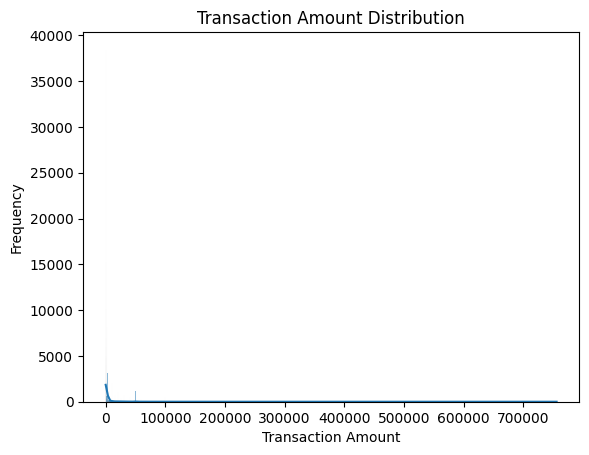

In [9]:
# Basic statistics on transaction amounts
sns.histplot(df['VALOR_TRANSACAO'], kde=True)
plt.title('Transaction Amount Distribution')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.show()

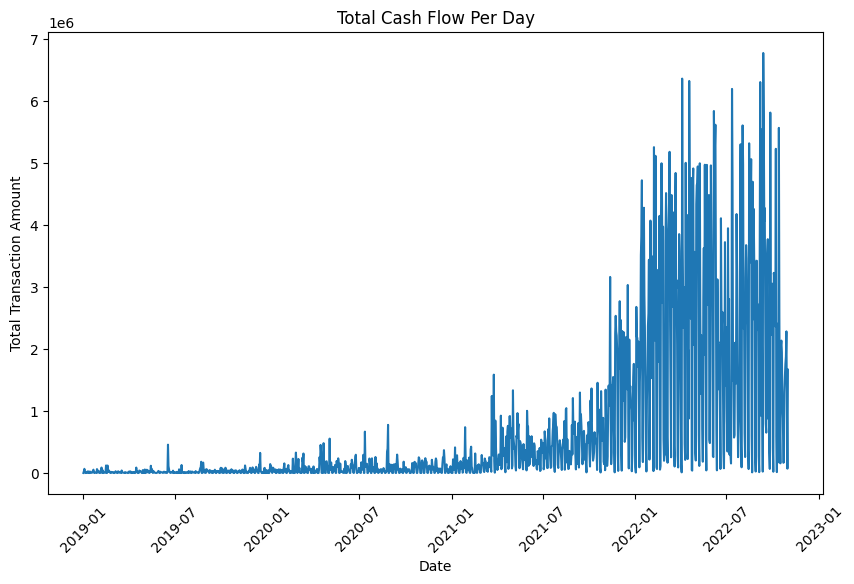

In [10]:
# Cash Flow Analysis: Plot total transactions per day
df['DATE'] = df['DATA_LANCAMENTO'].dt.date
daily_transactions = df.groupby('DATE')['VALOR_TRANSACAO'].sum()

plt.figure(figsize=(10,6))
daily_transactions.plot()
plt.title('Total Cash Flow Per Day')
plt.xlabel('Date')
plt.ylabel('Total Transaction Amount')
plt.xticks(rotation=45)
plt.show()

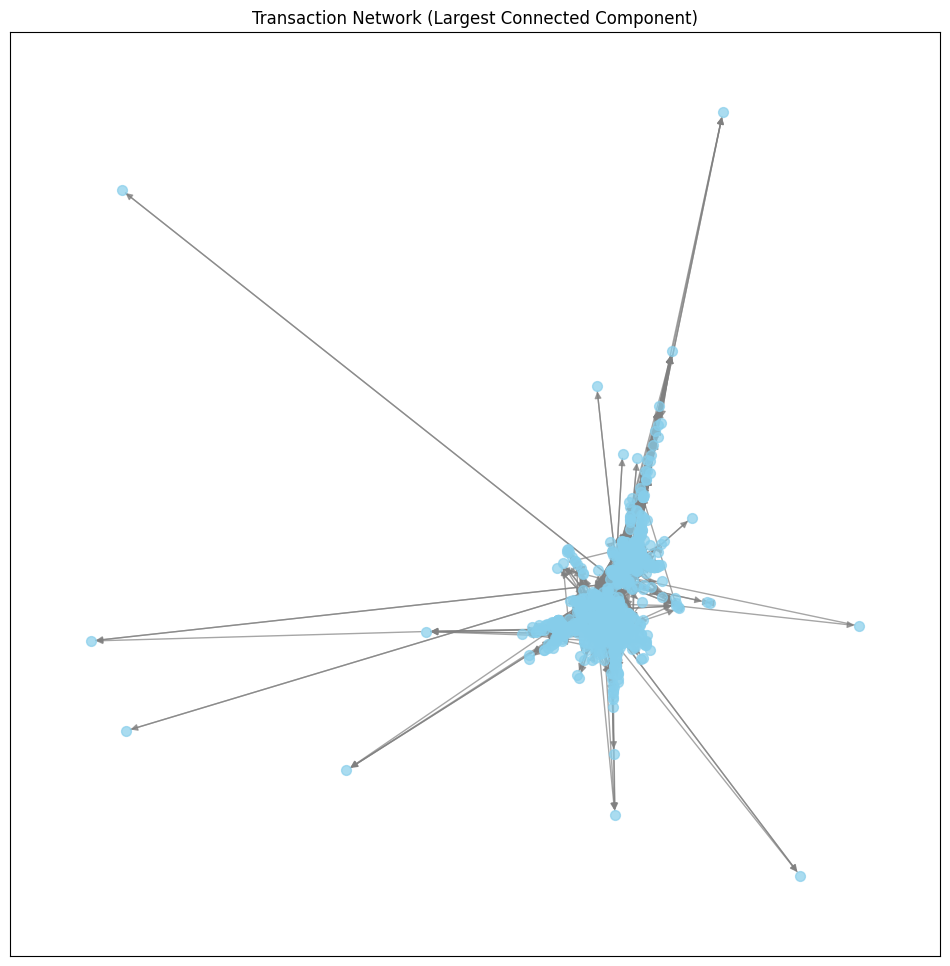

In [11]:
# Building the network: Sender-Receiver edges with weights
G = nx.DiGraph()

# Add edges to the graph: sender -> receiver with transaction amount as the weight
for _, row in df.iterrows():
    G.add_edge(row['SENDER_ACCOUNT'], row['RECEIVER_ACCOUNT'], weight=row['VALOR_TRANSACAO'])

# Visualizing the network: Display the largest connected component
largest_component = max(nx.strongly_connected_components(G), key=len)
subgraph = G.subgraph(largest_component)

plt.figure(figsize=(12, 12))
nx.draw_networkx(subgraph, node_size=50, with_labels=False, node_color='skyblue', edge_color='gray', alpha=0.7)
plt.title('Transaction Network (Largest Connected Component)')
plt.show()

In [12]:
# Centrality Analysis: Degree centrality
centrality = nx.degree_centrality(G)
centrality_df = pd.DataFrame(list(centrality.items()), columns=['Account', 'Centrality'])

# Top 10 accounts by centrality
top_10_accounts = centrality_df.sort_values(by='Centrality', ascending=False).head(10)
print(top_10_accounts)

                Account  Centrality
4059     197_1_93845618    0.244335
4060     197_1_40297681    0.059209
1799     748_810_949216    0.047583
21545   336_1_107391244    0.046273
17603    260_1_69014920    0.039658
15602   260_1_371904274    0.036416
4101    260_1_879654676    0.036154
25916  33_3109_10994448    0.035663
24548     1_4351_241237    0.034156
2407    260_1_994673247    0.033534


In [13]:
# Assortativity: Calculate assortativity coefficient (degree correlation)
assortativity = nx.degree_assortativity_coefficient(G)
print(f'Assortativity Coefficient: {assortativity}')

Assortativity Coefficient: -0.27615477460662763


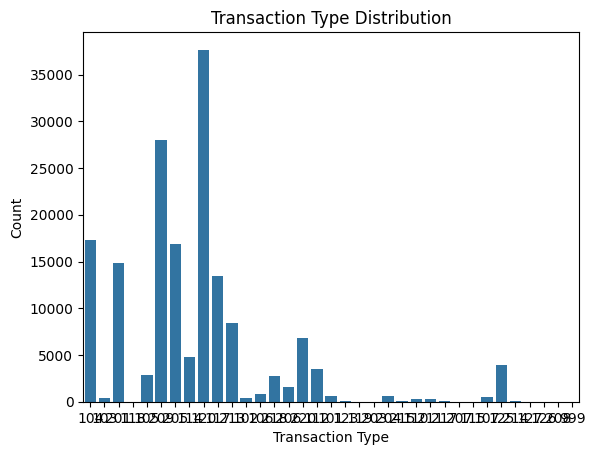

In [14]:
# Transaction Type Distribution
sns.countplot(data=df, x='CNAB')
plt.title('Transaction Type Distribution')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.show()

In [15]:
# Detection of Suspicious Transactions: Transactions with large amounts
suspicious_transactions = df[df['VALOR_TRANSACAO'] > df['VALOR_TRANSACAO'].quantile(0.95)]
print(f'Number of suspicious transactions: {len(suspicious_transactions)}')
print(suspicious_transactions[['SENDER_ACCOUNT', 'RECEIVER_ACCOUNT', 'VALOR_TRANSACAO']])

Number of suspicious transactions: 8265
           SENDER_ACCOUNT   RECEIVER_ACCOUNT  VALOR_TRANSACAO
244      237_2939_2930993  237_2764_10081653         41000.00
250     237_2764_10081653              EMPTY         41000.00
613     237_2764_10081653   341_7070_4528952         40000.00
615     237_2764_10081653   341_8953_4737110        142315.29
643        341_641_995584    237_504_8661511        100000.00
...                   ...                ...              ...
157852    336_1_112742491    104_966_1646054        140000.00
157860    336_1_112742491      0_704_5710893         36000.00
157864    336_1_112742491     208_50_5792578         85000.00
157876    336_1_112742491      260_1_2878220         94810.00
157883    336_1_112742491      336_1_2493887         55600.00

[8265 rows x 3 columns]


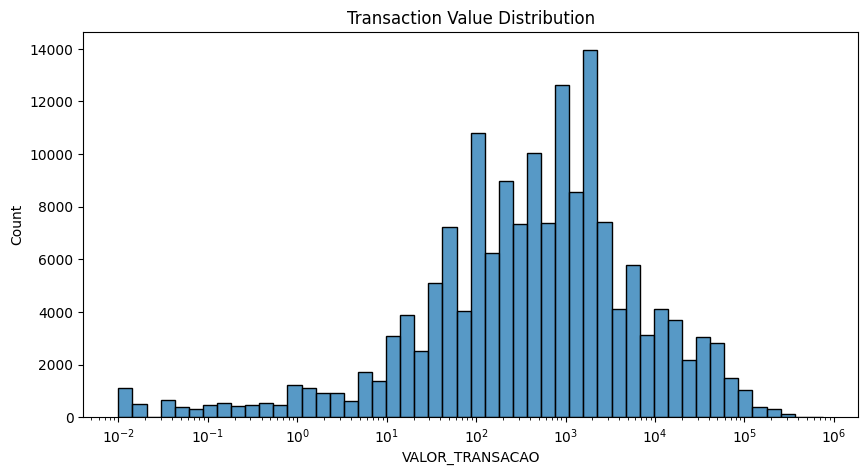

In [16]:
# Distribution of transaction values
plt.figure(figsize=(10, 5))
sns.histplot(df['VALOR_TRANSACAO'], bins=50, log_scale=True)
plt.title('Transaction Value Distribution')
plt.show()

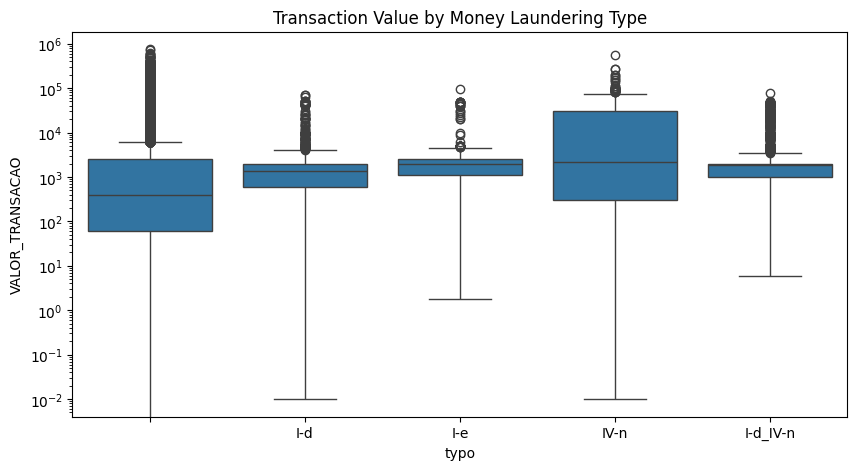

In [17]:
# Boxplot by money laundering type
plt.figure(figsize=(10, 5))
sns.boxplot(x='typo', y='VALOR_TRANSACAO', data=df)
plt.yscale('log')
plt.title('Transaction Value by Money Laundering Type')
plt.show()

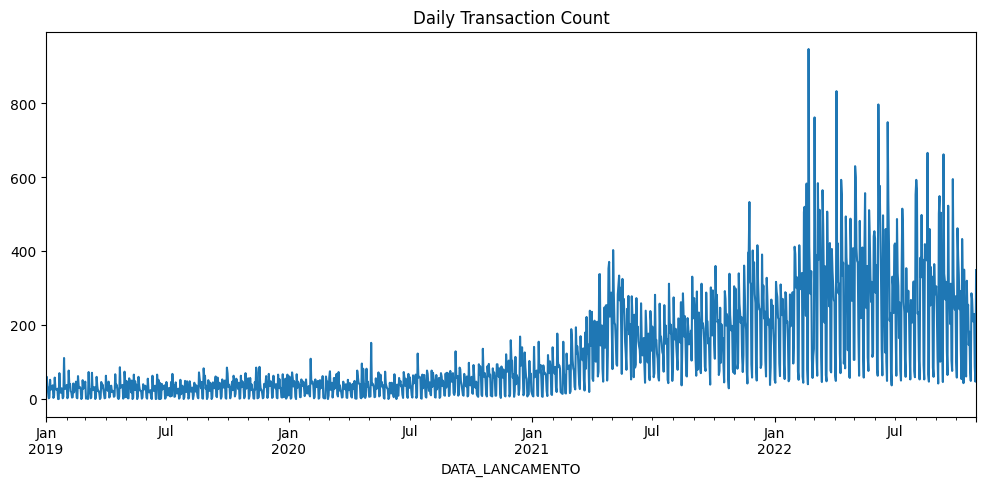

In [18]:
# Time series of transactions
df.set_index('DATA_LANCAMENTO').resample('D').size().plot(figsize=(12, 5))
plt.title('Daily Transaction Count')
plt.show()

In [19]:
df.columns

Index(['NUMERO_CASO', 'NUMERO_BANCO', 'NOME_BANCO', 'NUMERO_AGENCIA',
       'NUMERO_CONTA', 'TIPO', 'CPF_CNPJ_TITULAR', 'NOME_TITULAR',
       'DATA_LANCAMENTO', 'CPF_CNPJ_OD', 'NOME_PESSOA_OD', 'CNAB',
       'DESCRICAO_LANCAMENTO', 'VALOR_TRANSACAO', 'NATUREZA_LANCAMENTO', 'I-d',
       'I-e', 'IV-n', 'RAMO_ATIVIDADE_1', 'RAMO_ATIVIDADE_2',
       'RAMO_ATIVIDADE_3', 'LOCAL_TRANSACAO', 'NUMERO_DOCUMENTO',
       'NUMERO_DOCUMENTO_TRANSACAO', 'VALOR_SALDO', 'NATUREZA_SALDO',
       'NUMERO_BANCO_OD', 'NUMERO_AGENCIA_OD', 'NUMERO_CONTA_OD',
       'NOME_ENDOSSANTE_CHEQUE', 'DOC_ENDOSSANTE_CHEQUE', 'DIA_LANCAMENTO',
       'MES_LANCAMENTO', 'ANO_LANCAMENTO', 'CONTA_TITULAR', 'CONTA_OD',
       'SENDER_ACCOUNT', 'RECEIVER_ACCOUNT', 'typo', 'DATE'],
      dtype='object')

In [20]:
id_counts = df[df["typo"] == "I-d"].groupby("CONTA_TITULAR").size()
total_counts = df.groupby("CONTA_TITULAR").size()
id_ratio = (id_counts / total_counts).fillna(0)

In [21]:
accounts_df = pd.DataFrame({"CONTA_TITULAR": total_counts.index, "id_ratio": id_ratio})

# Creating clusters based on I-d
accounts_df["cluster"] = pd.cut(accounts_df["id_ratio"], bins=[-0.01, 0, 0.25, 0.5, 1.0], labels=[0, 1, 2, 3])

In [30]:
train_accounts, test_accounts = train_test_split(
    accounts_df["CONTA_TITULAR"], test_size=0.4, stratify=accounts_df["cluster"]
)

In [31]:
train_df = df[df["CONTA_TITULAR"].isin(train_accounts)]
test_df = df[df["CONTA_TITULAR"].isin(test_accounts)]

In [32]:
id_train_ratio = train_df["typo"].eq("I-d").mean()
id_test_ratio = test_df["typo"].eq("I-d").mean()

print(f"Proporção de 'I-d' no treino: {id_train_ratio:.4f}")
print(f"Proporção de 'I-d' no teste: {id_test_ratio:.4f}")

Proporção de 'I-d' no treino: 0.0956
Proporção de 'I-d' no teste: 0.0546


In [33]:
print(train_df["typo"].value_counts(normalize=True))
print(test_df["typo"].value_counts(normalize=True))

typo
            0.868743
I-d         0.095609
I-d_IV-n    0.028827
I-e         0.004326
IV-n        0.002495
Name: proportion, dtype: float64
typo
            0.877887
I-d         0.054629
I-d_IV-n    0.053414
I-e         0.011652
IV-n        0.002418
Name: proportion, dtype: float64
